# Corrected AreaSum Evaluation

Load the corrected AreaSum pickle produced by `AreaSumrun_streaming.py`, inspect one model, and compare mean corrected AreaSum against AMOC strength across models.


In [6]:
import pickle
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas
import xarray as xr
from xarray.coding.variables import SerializationWarning

warnings.filterwarnings("ignore", category=SerializationWarning)


In [7]:
project_root = Path("/glade/u/home/stevenxu/AMOCproject")
data_dir = Path("/glade/work/stevenxu/AMOC_models/downloads")
areasum_path = Path("/glade/work/stevenxu/AMOC_models/AreaSum_Allmodels_streaming.pkl")
plot_dir = project_root / "scripts/FgenEvaluation/AreaSum_plots"
plot_dir.mkdir(parents=True, exist_ok=True)

area_model = "MIROC6"
areasum_rho_min = 1025.0
last_n_years = 30
lat_bounds = (0, 60)
min_depth = 250
excluded_models = {"FGOALS-g3", "SAM0-UNICON", "E3SM-1-0", "GISS-E2-1-G-CC", "GISS-E2-2-G"}
target_models = None  # e.g. ["CanESM5", "MIROC6"]

time_range_pattern = re.compile(r"_(?P<start>\d{6})-(?P<end>\d{6})\.nc$")

if not areasum_path.exists():
    raise FileNotFoundError(
        f"AreaSum pickle not found: {areasum_path}. "
        "Run scripts/FgenCalculation/AreaSumrun_streaming.py first."
    )


In [8]:
def open_msftmz_dataset(path):
    last_error = None
    for engine in ("scipy", "h5netcdf"):
        try:
            return xr.open_dataset(
                path,
                engine=engine,
                decode_times=True,
                use_cftime=True,
            ), engine
        except Exception as exc:
            last_error = exc

    raise last_error


def parse_year_range(path):
    match = time_range_pattern.search(path.name)
    if match is None:
        raise ValueError(f"Could not parse year range from {path.name}")

    return int(match.group("start")[:4]), int(match.group("end")[:4])


def choose_last_n_year_files(paths, last_n_years=30):
    records = []
    for path in sorted(paths):
        start_year, end_year = parse_year_range(path)
        records.append(
            {
                "path": path,
                "start_year": start_year,
                "end_year": end_year,
            }
        )

    max_end_year = max(record["end_year"] for record in records)
    threshold_year = max_end_year - last_n_years + 1
    selected = []
    current_year = max_end_year

    while current_year >= threshold_year:
        candidates = [
            record
            for record in records
            if record["start_year"] <= current_year <= record["end_year"]
        ]

        if not candidates:
            raise ValueError(f"No file covers year {current_year}")

        best = min(
            candidates,
            key=lambda record: (
                record["start_year"],
                -record["end_year"],
                record["path"].name,
            ),
        )
        selected.append(best)
        current_year = best["start_year"] - 1

    selected = sorted(
        selected,
        key=lambda record: (
            record["start_year"],
            record["end_year"],
            record["path"].name,
        ),
    )
    return selected, threshold_year, max_end_year


def basin_labels(ds, basin_dim):
    for coord_name in ("sector", basin_dim, "region"):
        if coord_name not in ds:
            continue

        coord = ds[coord_name]
        if basin_dim not in coord.dims:
            continue

        values = np.asarray(coord.values)
        labels = []
        for value in values:
            if isinstance(value, bytes):
                label = value.decode("utf-8")
            elif isinstance(value, str):
                label = value
            else:
                value_array = np.asarray(value)
                if value_array.dtype.kind in {"S", "U"} and value_array.ndim >= 1:
                    pieces = value_array.tolist()
                    label = "".join(
                        piece.decode("utf-8") if isinstance(piece, bytes) else str(piece)
                        for piece in pieces
                    )
                else:
                    label = str(value)

            labels.append(label.strip().lower())

        return labels

    raise ValueError("No basin labels found")


def atlantic_basin_index(ds, basin_dim):
    labels = basin_labels(ds, basin_dim)
    preferred_labels = (
        "atlantic_arctic_ocean",
        "atlantic_arctic_extended_ocean",
        "atlantic_ocean",
        "atlantic",
        "a",
    )

    for preferred_label in preferred_labels:
        for index, label in enumerate(labels):
            if preferred_label == label or preferred_label in label:
                return index, labels

    raise ValueError(f"Could not identify the Atlantic basin in {labels}")


def build_amoc_climatology(paths, last_n_years=30):
    selected_records, threshold_year, max_end_year = choose_last_n_year_files(
        paths,
        last_n_years=last_n_years,
    )

    total_sum = None
    total_count = None
    basin_label = None
    engines = []

    for record in selected_records:
        ds, engine = open_msftmz_dataset(record["path"])
        engines.append(engine)

        with ds:
            data = ds["msftmz"]
            basin_dim = next(
                dim for dim in data.dims if dim not in ("time", "lev", "lat")
            )
            basin_index, labels = atlantic_basin_index(ds, basin_dim)
            basin_label = labels[basin_index]

            field = data.isel({basin_dim: basin_index}).load()
            years = ds["time"].dt.year.values
            time_index = np.where(
                (years >= threshold_year) & (years <= max_end_year)
            )[0]
            field = field.isel(time=time_index)

            summed = field.sum(dim="time", skipna=True)
            counted = field.notnull().sum(dim="time")
            total_sum = summed if total_sum is None else total_sum + summed
            total_count = counted if total_count is None else total_count + counted

    mean_field = (total_sum / total_count).rename("msftmz") / 1.0e9
    mean_field = mean_field.transpose("lev", "lat").sortby("lev").sortby("lat")
    mean_field.attrs["units"] = "Sv"

    metadata = {
        "threshold_year": threshold_year,
        "max_end_year": max_end_year,
        "basin_label": basin_label,
        "selected_files": [record["path"].name for record in selected_records],
        "engines": engines,
    }
    return mean_field, metadata


def amoc_strength(mean_field, lat_bounds=(20, 60), min_depth=500):
    clipped = mean_field.where(
        (mean_field["lat"] >= lat_bounds[0])
        & (mean_field["lat"] <= lat_bounds[1])
        & (mean_field["lev"] >= min_depth),
        drop=True,
    )
    return float(clipped.max().item())


def linear_regression_with_r_squared(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    fitted = slope * x + intercept
    ss_res = np.sum((y - fitted) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r_squared = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot
    return slope, intercept, r_squared


def plot_amoc_relationship(summary, x_column, xlabel, title, save_name, text_y=0.15):
    regression = summary[~summary["model"].isin(excluded_models)].copy()
    slope, intercept, r_squared = linear_regression_with_r_squared(
        regression[x_column],
        regression["AMOC_strength_Sv"],
    )

    x_line = np.linspace(
        regression[x_column].min(),
        regression[x_column].max(),
        200,
    )

    plt.figure(figsize=(8, 6))
    plt.scatter(
        regression[x_column],
        regression["AMOC_strength_Sv"],
        color="black",
    )
    plt.plot(x_line, slope * x_line + intercept, color="tab:red")

    for _, row in regression.iterrows():
        plt.text(
            row[x_column],
            row["AMOC_strength_Sv"],
            row["model"],
            fontsize=8,
            ha="left",
            va="bottom",
        )

    plt.text(
        0.05,
        text_y,
        f"y = {slope:.3f}x + {intercept:.3f}\nR^2 = {r_squared:.3f}",
        transform=plt.gca().transAxes,
        va="top",
        bbox={"facecolor": "white", "alpha": 0.8},
    )

    plt.xlabel(xlabel)
    plt.ylabel("AMOC strength (Sv)")
    plt.title(title)
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.savefig(plot_dir / save_name, dpi=300, bbox_inches="tight")
    plt.show()


In [9]:
amoc_model_files = {}

for model_dir in sorted(data_dir.iterdir()):
    msftmz_dir = model_dir / "msftmz"
    files = sorted(msftmz_dir.glob("*.nc")) if msftmz_dir.is_dir() else []
    if files:
        amoc_model_files[model_dir.name] = files

if target_models is not None:
    amoc_model_files = {
        model: amoc_model_files[model]
        for model in target_models
        if model in amoc_model_files
    }

print(f"Found {len(amoc_model_files)} model(s) with downloaded msftmz files.")
amoc_model_files.keys()


Found 19 model(s) with downloaded msftmz files.


dict_keys(['ACCESS-CM2', 'ACCESS-ESM1-5', 'CanESM5', 'CanESM5-1', 'E3SM-1-0', 'E3SM-1-1', 'E3SM-1-1-ECA', 'FGOALS-g3', 'GISS-E2-1-G-CC', 'GISS-E2-2-G', 'ICON-ESM-LR', 'MIROC6', 'MPI-ESM-1-2-HAM', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'SAM0-UNICON'])

In [10]:
amoc_climatology_dict = {}
amoc_summary_rows = []

for model, paths in amoc_model_files.items():
    mean_field, metadata = build_amoc_climatology(paths, last_n_years=last_n_years)
    amoc_climatology_dict[model] = mean_field
    amoc_summary_rows.append(
        {
            "model": model,
            "years": f"{metadata['threshold_year']}-{metadata['max_end_year']}",
            "basin": metadata["basin_label"],
            "files_used": len(metadata["selected_files"]),
            "engines": ",".join(sorted(set(metadata["engines"]))),
            "max_amoc_Sv": amoc_strength(
                mean_field,
                lat_bounds=lat_bounds,
                min_depth=min_depth,
            ),
        }
    )

amoc_summary = pandas.DataFrame(amoc_summary_rows)
amoc_summary = amoc_summary.sort_values("max_amoc_Sv", ascending=False).reset_index(drop=True)
amoc_summary


,model,years,basin,files_used,engines,max_amoc_Sv
0,FGOALS-g3,670-699,atlantic_arctic_ocean,1,scipy,36.944621
1,GISS-E2-2-G,2121-2150,atlantic_arctic_ocean,2,scipy,29.521201
2,GISS-E2-1-G-CC,1985-2014,atlantic_arctic_ocean,2,scipy,28.207784
3,SAM0-UNICON,671-700,atlantic_arctic_ocean,4,h5netcdf,26.836998
4,NorESM2-MM,1670-1699,atlantic_arctic_ocean,3,h5netcdf,24.401176
5,NorESM2-LM,2071-2100,atlantic_arctic_ocean,3,h5netcdf,24.263032
6,MPI-ESM-1-2-HAM,2820-2849,atlantic_arctic_ocean,2,h5netcdf,23.683532
7,MPI-ESM1-2-LR,2820-2849,atlantic_arctic_ocean,2,h5netcdf,23.016497
8,MRI-ESM2-0,2521-2550,atlantic_arctic_ocean,1,h5netcdf,22.469255
9,ACCESS-CM2,1420-1449,atlantic_arctic_ocean,3,h5netcdf,21.852972


In [11]:
with areasum_path.open("rb") as f:
    areasum_dict = pickle.load(f)

if target_models is not None:
    areasum_dict = {
        model: areasum_dict[model]
        for model in target_models
        if model in areasum_dict
    }

if area_model not in areasum_dict:
    available = ", ".join(sorted(areasum_dict))
    raise KeyError(f"{area_model} is not in {areasum_path}. Available models: {available}")

areasum_by_time = areasum_dict[area_model].copy()
areasum_by_time.head()


,time_index,time,AreaSum
0,0,3680-01-16 12:00:00,1.037666e+13
1,1,3680-02-15 12:00:00,1.026506e+13
2,2,3680-03-16 12:00:00,1.009096e+13
3,3,3680-04-16 00:00:00,6.082540e+12
4,4,3680-05-16 12:00:00,3.256181e+12


In [12]:
areasum_summary = pandas.DataFrame(
    [
        {
            "model": area_model,
            "rho_min": areasum_by_time.attrs.get("rho_min", areasum_rho_min),
            "n_time": len(areasum_by_time),
            "AreaSum_mean": areasum_by_time["AreaSum"].mean(),
            "AreaSum_min": areasum_by_time["AreaSum"].min(),
            "AreaSum_max": areasum_by_time["AreaSum"].max(),
            "AreaSum_std": areasum_by_time["AreaSum"].std(),
        }
    ]
)

mean_areasum = areasum_summary.loc[0, "AreaSum_mean"]
print(f"{area_model} corrected mean AreaSum = {mean_areasum:.6e} m^2")
areasum_summary


MIROC6 corrected mean AreaSum = 7.304495e+12 m^2


,model,rho_min,n_time,AreaSum_mean,AreaSum_min,AreaSum_max,AreaSum_std
0,MIROC6,1025.0,240,7.304495e+12,1.310764e+12,1.093150e+13,3.626974e+12


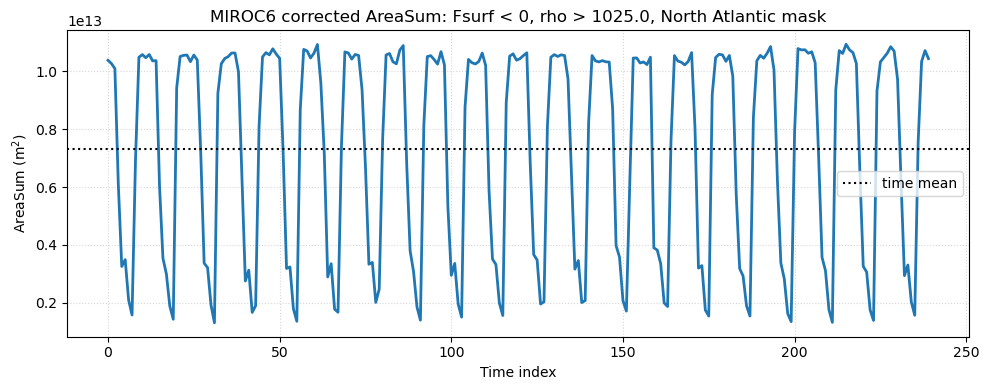

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    areasum_by_time["time_index"],
    areasum_by_time["AreaSum"],
    color="tab:blue",
    linewidth=2,
)
ax.axhline(mean_areasum, color="black", linestyle=":", label="time mean")
ax.set_xlabel("Time index")
ax.set_ylabel("AreaSum (m$^2$)")
ax.set_title(
    f"{area_model} corrected AreaSum: Fsurf < 0, rho > {areasum_rho_min}, North Atlantic mask"
)
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend()
fig.tight_layout()
fig.savefig(
    plot_dir / f"{area_model}_corrected_areasum_timeseries.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


In [14]:
common_models = sorted(set(amoc_climatology_dict) & set(areasum_dict))
models_only_in_amoc = sorted(set(amoc_climatology_dict) - set(areasum_dict))
models_only_in_areasum = sorted(set(areasum_dict) - set(amoc_climatology_dict))

print(f"Models used in both AMOC and AreaSum: {len(common_models)}")
print(f"Only in AMOC: {models_only_in_amoc}")
print(f"Only in AreaSum: {models_only_in_areasum}")

amoc_strength_by_model = {
    model: amoc_strength(
        amoc_climatology_dict[model],
        lat_bounds=lat_bounds,
        min_depth=min_depth,
    )
    for model in common_models
}

amoc_areasum_summary = pandas.DataFrame(
    [
        {
            "model": model,
            "AMOC_strength_Sv": amoc_strength_by_model[model],
            "AreaSum_mean": areasum_dict[model]["AreaSum"].mean(),
        }
        for model in common_models
    ]
).sort_values("AMOC_strength_Sv", ascending=False).reset_index(drop=True)

amoc_areasum_summary


Models used in both AMOC and AreaSum: 17
Only in AMOC: ['E3SM-1-1', 'E3SM-1-1-ECA']
Only in AreaSum: ['CAS-ESM2-0', 'FGOALS-f3-L']


,model,AMOC_strength_Sv,AreaSum_mean
0,FGOALS-g3,36.944621,1.416070e+12
1,GISS-E2-2-G,29.521201,1.013690e+13
2,GISS-E2-1-G-CC,28.207784,8.722776e+12
3,SAM0-UNICON,26.836998,4.515509e+12
4,NorESM2-MM,24.401176,8.057175e+12
5,NorESM2-LM,24.263032,7.646896e+12
6,MPI-ESM-1-2-HAM,23.683532,7.551026e+12
7,MPI-ESM1-2-LR,23.016497,7.443625e+12
8,MRI-ESM2-0,22.469255,7.644348e+12
9,ACCESS-CM2,21.852972,7.406543e+12


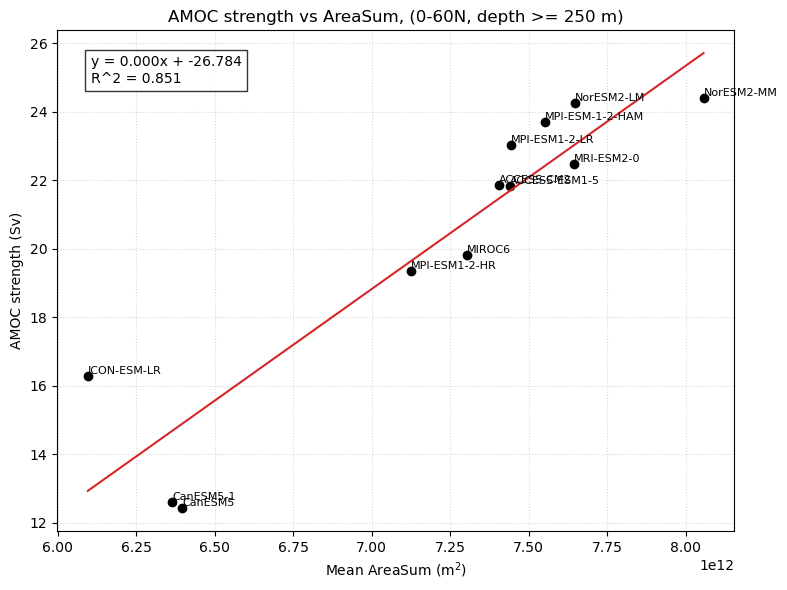

In [16]:
plot_amoc_relationship(
    amoc_areasum_summary,
    "AreaSum_mean",
    "Mean AreaSum (m$^2$)",
    f"AMOC strength vs AreaSum, ({lat_bounds[0]}-{lat_bounds[1]}N, depth >= {min_depth} m)",
    "amoc_vs_areasum.png",
    text_y=0.95,
)
